## <font color = '#6495ED'>  ______________________ **Text Mining - Stock Sentiment** _____________________
#### _______________________________________________Academic Year: 2024/2025 _____________________________________________

<div style="text-align: center;">
    <strong>Group 31</strong>
    <table style="margin: 0 auto; border-collapse: collapse; border: 1px solid black;">
        <tr>
            <th style="border: 1px solid white; padding: 8px;">Name</th>
            <th style="border: 1px solid white; padding: 8px;">Student ID</th>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">David Cascão</td>
            <td style="border: 1px solid white; padding: 8px;">20240851</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Elcano Gaspar</td>
            <td style="border: 1px solid white; padding: 8px;">20241021</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Jorge Cordeiro</td>
            <td style="border: 1px solid white; padding: 8px;">20240594</td>
        </tr>
        <tr>
            <td style="border: 1px solid white; padding: 8px;">Rui Reis</td>
            <td style="border: 1px solid white; padding: 8px;">20240854</td>
        </tr>
    </table>
</div>

### <font color = '#6495ED'>**Introduction**</font>

#### *Objective:*
The goal of this project is to develop an NLP model capable of predicting stock market sentiment analysis from tweets using both traditional and transformer-based NLP models.
#### *Corpora:*
- Training Dataset: Presents the tweets (“text”) and the sentiment label (“label”). Each tweet can have one of the following labels: Bearish (0), Bullish (1), or Neutral (2). Bullish is typically a positive market performance, while bearish is the opposite.
- Test Dataset: The structure of these dataset is the same as the train set, except that it does not contain the “label” column.
#### *Methodology:*
The project will follow these steps:
- Exploratory Data Analysis (EDA)
- Corpus split
- Data Preprocessing
- Feature Engineering
- Classification Models
#### *Success Metrics:*
Our primary metric will be F1 Score, Recall and Precision, as we are dealing with an imbalanced class problem, but also the Accuracy.
#### **Variable description:**

| **ATTRIBUTE**               | **DESCRIPTION**                                                                                   |
|-----------------------------|---------------------------------------------------------------------------------------------------|
| text               | Tweets about market stocks.                                                                         |
| label               | Market sentiment Bearish (0), Bullish (1), or Neutral (2).                                                  |

### <font color = '#6495ED'>  **Libraries, Functions, Configuration and Datasets** </font>

#### <font color = '#6495ED'> **Import the Needed Libraries** </font>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import csv
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
#from transformers import pipeline, AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from feature_engineering_utils import apply_undersampling, apply_smote, get_class_weights
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline 
from sklearn.model_selection import cross_val_predict
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import StratifiedKFold
#from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import os

#models
#from tensorflow.keras.preprocessing.text import Tokenizer
#from tensorflow.keras.preprocessing.sequence import pad_sequences

#from keras.models import Sequential
#from keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Flatten

#transformers models 
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import Dataset
import torch

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [4]:
# %%capture
#!pip install datasets transformers sentence-transformers openai

#### <font color = '#6495ED'> **Setup and Configuration** </font>

In [5]:
# permanently set the display option to show all columns
pd.set_option('display.max_columns', None)

In [6]:
# Set seaborn style and matplotlib defaults
sns.set(style="whitegrid", color_codes= "#152645", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.dpi'] = 100

#### <font color = '#6495ED'>**Load the Dataset** </font>

In [7]:
train_trad = pd.read_csv("train_preprocessed_trad.csv")
val_trad   = pd.read_csv("val_preprocessed_trad.csv")
test_trad  = pd.read_csv("test_preprocessed_trad.csv")

train_bert = pd.read_csv("train_preprocessed_bert.csv")
val_bert   = pd.read_csv("val_preprocessed_bert.csv")
test_bert  = pd.read_csv("test_preprocessed_bert.csv")

In [8]:
train_trad.head()

,Unnamed: 0,clean_text,label
0,2186,nasdaq price senior note,2
1,6819,future,1
2,6157,$econx november nonfarm private payroll consensus,0
3,2462,twitter user explain kohl stock got obliterate...,0
4,4097,agilysys restaurant find sustainable method li...,2


In [9]:
train_trad.isna().sum()

Unnamed: 0    0
clean_text    7
label         0
dtype: int64

In [10]:
val_trad.isna().sum()

Unnamed: 0    0
clean_text    1
label         0
dtype: int64

In [11]:
test_trad.isna().sum()

Unnamed: 0    0
clean_text    0
dtype: int64

In [ ]:
# Remove rows where clean_text is NaN
train_trad = train_trad.dropna(subset=['clean_text'])
val_trad = val_trad.dropna(subset=['clean_text'])

In [13]:
train_bert.isna().sum()

Unnamed: 0              0
text_for_transformer    0
label                   0
dtype: int64

In [14]:
test_bert.isna().sum()

Unnamed: 0              0
text_for_transformer    0
dtype: int64

In [15]:
val_bert.isna().sum()

Unnamed: 0              0
text_for_transformer    0
label                   0
dtype: int64

In [16]:
train_trad.head()

,Unnamed: 0,clean_text,label
0,2186,nasdaq price senior note,2
1,6819,future,1
2,6157,$econx november nonfarm private payroll consensus,0
3,2462,twitter user explain kohl stock got obliterate...,0
4,4097,agilysys restaurant find sustainable method li...,2


In [17]:
train_bert.head()

,Unnamed: 0,text_for_transformer,label
0,2186,Nasdaq prices 600M of 0.% senior notes,2
1,6819,Futures up <URL>,1
2,6157,$ECONX: November Nonfarm Private Payrolls 125K...,0
3,2462,Twitter users explain why Kohl's stock just go...,0
4,4097,Agilysys : Restaurants Find Sustainable Method...,2


#### <font color = '#6495ED'> **1. Deep Learning Models** </font>

In [60]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 100
embedding_dim = 100

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(train_trad['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train_trad['clean_text'])
X_val_seq   = tokenizer.texts_to_sequences(val_trad['clean_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_trad['clean_text'])

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

y_train = train_trad['label'].values
y_val   = val_trad['label'].values

In [61]:
embedding_index = {}
with open("glove.6B.100d.txt", encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coeffs

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, idx in tokenizer.word_index.items():
    if idx < max_words:
        vec = embedding_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

In [62]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, Flatten
from keras.optimizers import Adam

def build_optimized_bilstm_model():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=embedding_dim,
                        weights=[embedding_matrix], trainable=False))
    model.add(Bidirectional(LSTM(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_optimized_mlp_model():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=embedding_dim,
                        weights=[embedding_matrix], trainable=False))
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [63]:
def run_cv_and_eval_best_model_with_callbacks(X_train, y_train, X_val, y_val, model_fn, model_name, epochs=20, batch_size=64):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    best_f1 = -1
    best_model = None
    best_history = None

    histories = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"\n Fold {fold+1} - {model_name}")
        X_tr, X_val_ = X_train[train_idx], X_train[val_idx]
        y_tr, y_val_ = y_train[train_idx], y_train[val_idx]

        model = model_fn()

        # Callbacks
        checkpoint_path = f"{model_name}_fold{fold+1}.keras"
        callbacks = [
            EarlyStopping(patience=3, restore_best_weights=True),
            ModelCheckpoint(filepath=checkpoint_path, save_best_only=True)
        ]

        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_val_, y_val_),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=callbacks
        )

        histories.append(history)

        # Evaluation for fold selection
        y_pred_fold = np.argmax(model.predict(X_val_), axis=1)
        f1 = f1_score(y_val_, y_pred_fold, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_history = history

    print(f"\n Best model from CV for {model_name}: F1-macro = {best_f1:.4f}")

    # Final Evaluation on Validation Set
    print(f"\n Final Evaluation on Validation Set for {model_name}:")
    y_val_pred = np.argmax(best_model.predict(X_val), axis=1)
    print(classification_report(y_val, y_val_pred, digits=3))

    cm = confusion_matrix(y_val, y_val_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} - Final Evaluation (Validation Set)")
    plt.grid(False)
    plt.show()

    # Plot learning curves for best model
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(best_history.history['loss'], label='Train Loss')
    plt.plot(best_history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} - Loss (Best Fold)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(best_history.history['accuracy'], label='Train Acc')
    plt.plot(best_history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} - Accuracy (Best Fold)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



 Fold 1 - BiLSTM + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step

 Fold 2 - BiLSTM + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step

 Fold 3 - BiLSTM + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step

 Fold 4 - BiLSTM + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step

 Fold 5 - BiLSTM + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step

 Best model from CV for BiLSTM + GloVe: F1-macro = 0.6956

 Final Evaluation on Validation Set for BiLSTM + GloVe:
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step
              precision    recall  f1-score   support

           0      0.732     0.465     0.569       288
           1      0.677     0.491     0.569       385
           2      0.801     0.938     0.864      1235

    accuracy                          0.776      1908
   macro avg      0.737     0.631     0.667      1908
weighted avg      0.766     0.776     0.760      1908



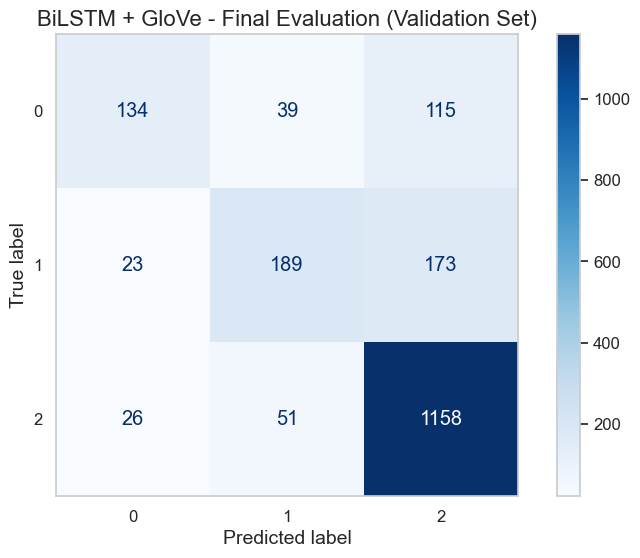

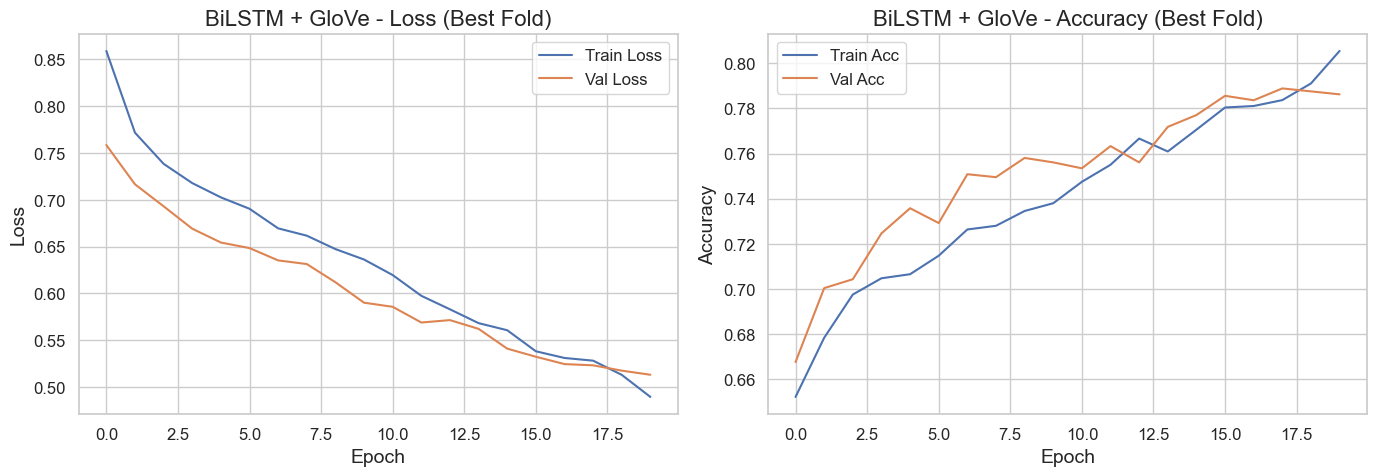


 Fold 1 - MLP + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Fold 2 - MLP + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Fold 3 - MLP + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Fold 4 - MLP + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

 Fold 5 - MLP + GloVe
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

 Best model from CV for MLP + GloVe: F1-macro = 0.6070

 Final Evaluation on Validation Set for MLP + GloVe:
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0      0.592     0.358     0.446       288
           1      0.528     0.447     0.484       385
           2      0.781     0.890     0.832      1235

    accuracy                          0.720      1908
   macro avg      0.633     0.565     0.587      1908
weighted avg      0.701     0.720     0.703      1908



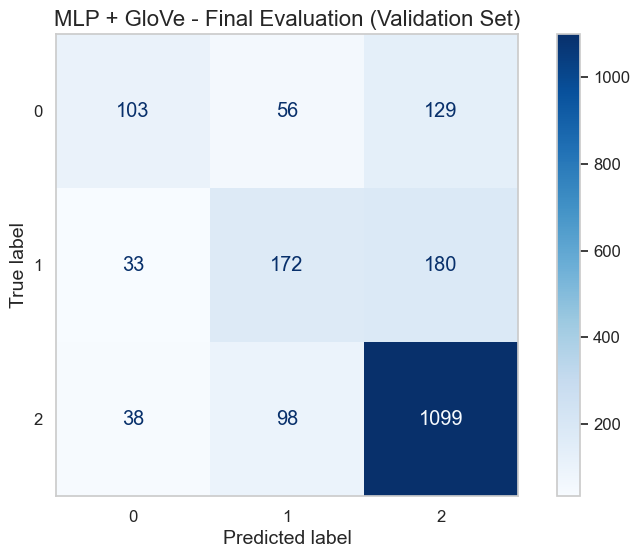

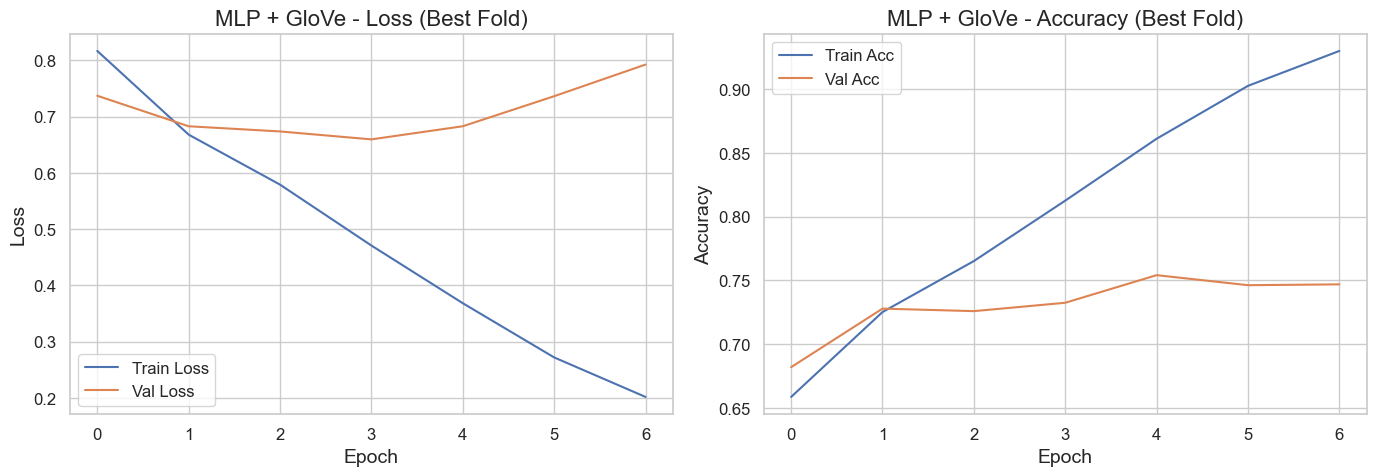

In [64]:
X_train_glove = np.array(X_train_pad)
y_train_glove = np.array(y_train)
X_val_glove   = np.array(X_val_pad)
y_val_glove   = np.array(y_val)

run_cv_and_eval_best_model_with_callbacks(X_train_glove, y_train_glove, X_val_glove, y_val_glove, build_optimized_bilstm_model, "BiLSTM + GloVe")
run_cv_and_eval_best_model_with_callbacks(X_train_glove, y_train_glove, X_val_glove, y_val_glove, build_optimized_mlp_model, "MLP + GloVe")